# 02. DECam Streak List Clean-up by Gaussian Fitting
Written by Kiyoaki Okudaira<br>
*University of Washington / Kyushu University / IAU CPS SatHub<br>
(kiyoaki@uw.edu or okudaira.kiyoaki.528@s.kyushu-u.ac.jp)<br>
<br>
This code is written for ASTR 499 undergraduate research with Dr. Meredith.<br>
Cleanup DECAM streak list by Gaussian Fitting<br>
<br>
**History** (Major update only)<br>
coding 2025-11-09 : 1st coding<br>
update 2025-11-16 : adapted for Middle Earth<br>
update 2025-11-23 : adapted for sp library<br>
update 2026-05-02 : output filename changed & parallel processing<br>
update 2026-05-31 : enhance readability

### Import and initial settings
**Standard libraries**

In [1]:
# Default libraries
from os import path
import pickle
from tqdm.notebook import tqdm

# astropy
from astropy.table import Table,hstack
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS

from scipy.stats import sigmaclip

# others
import matplotlib.pyplot as plt
import numpy as np

**Satphotometry library**

In [2]:
import satphotometry as sp

**Import file settings**

In [7]:
# project directory
PATH_project = '/astro/store/shire/kiyoaki/ASTR499/'

PATH_input   = PATH_project + 'input/'
PATH_output  = PATH_project + 'output/'

PATH_image   = PATH_input  + 'fits_data/'
PATH_session = PATH_output + 'session/'

# ORIGINAL streak list from Alex
fname_streak_list = 'streaks_augmented_20230817.csv'
PATH_streak_list  = fname_streak_list + 'decam_streak_list/' + fname_streak_list

**Process method setting**

In [8]:
paralell_process = False
if paralell_process:
    from concurrent.futures import ThreadPoolExecutor, as_completed

### Read DECam streak list
Import DECam cleaned streak list

In [9]:
data = Table.read(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_00_masked_by_year.csv')
data = data.group_by("archive_filename")
data

streakID,filename,rnum,ra_1,ra_2,ra_3,ra_4,dec_1,dec_2,dec_3,dec_4,expnum,ccdnum,band,width,height,area,archive_filename,filesize,dateobs_center,dateobs_min,dateobs_max,airmass,seeing,magzero,img_availability,md5sum
int64,str37,int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str1,float64,float64,float64,str82,int64,str27,int64,int64,float64,float64,float64,str4,str32
1,D00807895_g_c04_r5801p01_hstreak.fits,1,6.051207,6.057022,6.740975,6.735182,-74.372456,-74.370547,-74.51886,-74.520786,807895,4,g,8.890159,849.139349,7548.98354,/net/archive/pipe/20181231/ct4m/2018A-0273/c4d_190101_012442_ooi_g_ls9.fits.fz,327418560,2019-01-01T01:26:22.930752Z,--,--,1.53,0.0,30.129,True,dae4e3db615628d24cf074f47cc24c43
2,D00807895_g_c07_r5801p01_hstreak.fits,1,10.392105,10.399879,10.054193,10.046367,-74.367004,-74.368267,-74.521012,-74.519736,807895,7,g,8.80596,643.227663,5664.237318,/net/archive/pipe/20181231/ct4m/2018A-0273/c4d_190101_012442_ooi_g_ls9.fits.fz,327418560,2019-01-01T01:26:22.930752Z,--,--,1.53,0.0,30.129,True,dae4e3db615628d24cf074f47cc24c43
3,D00807895_g_c09_r5801p01_hstreak.fits,1,6.797967,6.805848,7.543088,7.535246,-74.534785,-74.532183,-74.687419,-74.690051,807895,9,g,12.04113,899.129083,10826.530272,/net/archive/pipe/20181231/ct4m/2018A-0273/c4d_190101_012442_ooi_g_ls9.fits.fz,327418560,2019-01-01T01:26:22.930752Z,--,--,1.53,0.0,30.129,True,dae4e3db615628d24cf074f47cc24c43
4,D00807895_g_c11_r5801p01_hstreak.fits,1,10.011417,10.02208,9.667898,9.657162,-74.533723,-74.535465,-74.688015,-74.686256,807895,11,g,12.004395,645.042297,7743.34221,/net/archive/pipe/20181231/ct4m/2018A-0273/c4d_190101_012442_ooi_g_ls9.fits.fz,327418560,2019-01-01T01:26:22.930752Z,--,--,1.53,0.0,30.129,True,dae4e3db615628d24cf074f47cc24c43
5,D00807895_g_c15_r5801p01_hstreak.fits,1,7.604972,7.610737,8.319146,8.313417,-74.70339,-74.701442,-74.844476,-74.846443,807895,15,g,8.897264,844.858558,7516.929737,/net/archive/pipe/20181231/ct4m/2018A-0273/c4d_190101_012442_ooi_g_ls9.fits.fz,327418560,2019-01-01T01:26:22.930752Z,--,--,1.53,0.0,30.129,True,dae4e3db615628d24cf074f47cc24c43
6,D00807895_g_c16_r5801p01_hstreak.fits,1,9.496947,9.507719,9.270792,9.259974,-74.75343,-74.755196,-74.854362,-74.852584,807895,16,g,12.016842,421.220528,5061.740462,/net/archive/pipe/20181231/ct4m/2018A-0273/c4d_190101_012442_ooi_g_ls9.fits.fz,327418560,2019-01-01T01:26:22.930752Z,--,--,1.53,0.0,30.129,True,dae4e3db615628d24cf074f47cc24c43
7,D00807895_g_c17_r5801p01_streak.fits,1,9.541584,9.529387,9.624206,9.636382,-74.741626,-74.739619,-74.699573,-74.701574,807895,17,g,13.629176,169.932589,2316.04117,/net/archive/pipe/20181231/ct4m/2018A-0273/c4d_190101_012442_ooi_g_ls9.fits.fz,327418560,2019-01-01T01:26:22.930752Z,--,--,1.53,0.0,30.129,True,dae4e3db615628d24cf074f47cc24c43
8,D00807895_g_c22_r5801p01_hstreak.fits,1,9.226051,9.236896,8.866798,8.855883,-74.866082,-74.867861,-75.019842,-75.018045,807895,22,g,12.037451,647.407566,7793.136687,/net/archive/pipe/20181231/ct4m/2018A-0273/c4d_190101_012442_ooi_g_ls9.fits.fz,327418560,2019-01-01T01:26:22.930752Z,--,--,1.53,0.0,30.129,True,dae4e3db615628d24cf074f47cc24c43
9,D00807895_g_c28_r5801p01_hstreak.fits,1,8.820581,8.834329,8.450296,8.436465,-75.031324,-75.033611,-75.185713,-75.183402,807895,28,g,15.204608,652.715785,9924.287784,/net/archive/pipe/20181231/ct4m/2018A-0273/c4d_190101_012442_ooi_g_ls9.fits.fz,327418560,2019-01-01T01:26:22.930752Z,--,--,1.53,0.0,30.129,True,dae4e3db615628d24cf074f47cc24c43


In [11]:
data = data[11:12]

## Gaussian Fitting
### Functions
**Streak coorinates**<br>
Determine coordinates of the streak start & end from Alex's streak list

In [12]:
def determine_streak_coord(row,ccd_wcs):
    # Skycord convertion
    c1 = SkyCoord(row["ra_1"]*u.deg, row["dec_1"]*u.deg)
    c2 = SkyCoord(row["ra_2"]*u.deg, row["dec_2"]*u.deg)
    c3 = SkyCoord(row["ra_3"]*u.deg, row["dec_3"]*u.deg)
    c4 = SkyCoord(row["ra_4"]*u.deg, row["dec_4"]*u.deg)

    x1, y1 = ccd_wcs.world_to_pixel(c1)
    x2, y2 = ccd_wcs.world_to_pixel(c2)
    x3, y3 = ccd_wcs.world_to_pixel(c3)
    x4, y4 = ccd_wcs.world_to_pixel(c4)

    xs = [x1, x2, x3, x4, x1]
    ys = [y1, y2, y3, y4, y1]

    # Calculate length between points
    d12 = c1.separation(c2).to(u.arcsec).value
    d13 = c1.separation(c3).to(u.arcsec).value
    d14 = c1.separation(c4).to(u.arcsec).value

    dists = sorted([d12, d13, d14])
    rank_dict = {v: i+1 for i, v in enumerate(dists)}
    rank = [rank_dict[v] for v in [d12, d13, d14]]

    if rank[0] == 1:
        coord_1 = sp.LEOphotometry.radec_to_pixel((row["ra_1"]+row["ra_2"])/2,(row["dec_1"]+row["dec_2"])/2,ccd_wcs)
        coord_2 = sp.LEOphotometry.radec_to_pixel((row["ra_3"]+row["ra_4"])/2,(row["dec_3"]+row["dec_4"])/2,ccd_wcs)
    elif rank[1] == 1:
        coord_1 = sp.LEOphotometry.radec_to_pixel((row["ra_1"]+row["ra_3"])/2,(row["dec_1"]+row["dec_3"])/2,ccd_wcs)
        coord_2 = sp.LEOphotometry.radec_to_pixel((row["ra_2"]+row["ra_4"])/2,(row["dec_2"]+row["dec_4"])/2,ccd_wcs)
    elif rank[2] == 1:
        coord_1 = sp.LEOphotometry.radec_to_pixel((row["ra_1"]+row["ra_4"])/2,(row["dec_1"]+row["dec_4"])/2,ccd_wcs)
        coord_2 = sp.LEOphotometry.radec_to_pixel((row["ra_2"]+row["ra_3"])/2,(row["dec_2"]+row["dec_3"])/2,ccd_wcs)
    return coord_1,coord_2,xs,ys

**Gaussian fitting**

In [13]:
def streak_gaussian_analysis(rotated_img):
    org_section = np.arange(0, len(rotated_img[0])-50, 50)
    popts = []
    section = []

    # Gaussian fitting
    for f in org_section:
        section_img = [row[f:f+50] for row in rotated_img]
        
        counts,coordinates = sp.LEOphotometry.count_1d(section_img)
        try:
            popt,_,_,_ = sp.LEOphotometry.gauss_fitting(counts,coordinates,False)
            popts.append(popt)
            section.append(f)
        except RuntimeError:
            pass
    if org_section[-1] + 50 < len(rotated_img[0]):
        section_img = [row[org_section[-1]+50:] for row in rotated_img]

        counts,coordinates = sp.LEOphotometry.count_1d(section_img)
        try:
            popt,_,_,_ = sp.LEOphotometry.gauss_fitting(counts,coordinates,False)
            popts.append(popt)
            section.append(org_section[-1] + 50)
        except RuntimeError:
            pass
    
    section = np.array(section)

    # fitting result
    amplitude = np.array([f[0] for f in popts])
    ground = np.array([f[3] for f in popts])
    mu = np.array([f[1] for f in popts])
    sigma = np.array([f[2] for f in popts])

    return section,amplitude,ground,mu,sigma

### Gaussian fitting (initial)
**Canvas**

In [14]:
streak_ID_list = [0] * len(data)

file_availablity_list   = [False] * len(data)
gauss_availability_list = [False] * len(data)

initial_gauss_y_list   = [[] for _ in range(len(data))]
initial_amplitude_list = [[] for _ in range(len(data))]
initial_ground_list    = [[] for _ in range(len(data))]
initial_mu_list        = [[] for _ in range(len(data))]
initial_sigma_list     = [[] for _ in range(len(data))]

initial_streak_coord_list = [[] for _ in range(len(data))]
initial_rt_angle_list  = [None] * len(data)

**Gaussian fitting (single processing)**

In [ ]:
if paralell_process is False:
    for row in tqdm(data[0:20]):
        # File information
        basename = path.basename(row["archive_filename"])
        md5sum = row["md5sum"]
        expnum = row["expnum"]
        ccdnum = row["ccdnum"]
        streak_ID = row["streakID"]
        idx = np.where(data["streakID"] == streak_ID)[0][0]

        streak_ID_list[idx] = streak_ID

        save_path = PATH_image + path.splitext(path.splitext(basename)[0])[0] + "_CCD_{0}".format(ccdnum) + path.splitext(path.splitext(basename)[0])[1] + path.splitext(basename)[1]

        if not path.exists(save_path):
            sp.noirlab.retrieve_fits_nocash(md5sum, save_path, ccdnum)
        
        # Read Image file
        hdu = fits.open(save_path)

        try:
            main_header = hdu[0].header
            ccd_header = hdu[1].header
            ccd_data = hdu[1].data
            ccd_wcs = WCS(ccd_header)
            file_availablity_list[idx] = True
        except:
            print("Error : Broken FITS file (EXPNUM : {0} / CCDNUM : {1} | Streak ID {2})".format(expnum,ccdnum,streak_ID))
            continue

        # Read metadata
        metadata = sp.fitsparser.LEOfitsparser.parse_metadata(main_header,ccd_header,[],[],True,False)
        matadata = sp.fitsparser.ASTR499.integrate_ALEX_metadata(metadata,row)

        # initial rotation
        coord_1,coord_2,_,_ = determine_streak_coord(row,ccd_wcs)

        try:
            rt_angle = sp.imgrotation.determine_rotation_angle(coord_1,coord_2)
            initial_streak_coord_list[idx] = [coord_1,coord_2]
            initial_rt_angle_list[idx] = rt_angle
            rotated_img = sp.imgrotation.rotate_image(ccd_data, rt_angle, [coord_1,coord_2], True, 100)
        except:
            print("Error : Streak length is too short (EXPNUM : {0} / CCDNUM : {1} | Streak ID {2})".format(expnum,ccdnum,streak_ID))
            continue

        try:
            if len(rotated_img[0]) < 50:
                print("Error : Streak length is too short (EXPNUM : {0} / CCDNUM : {1} | Streak ID {2})".format(expnum,ccdnum,streak_ID))
                continue
        except:
            print("Error : Streak length is too short (EXPNUM : {0} / CCDNUM : {1} | Streak ID {2})".format(expnum,ccdnum,streak_ID))
            continue

        # determine rotation angle
        try:
            section,amplitude,ground,mu,sigma = streak_gaussian_analysis(rotated_img)
            if len(section) > 0:
                initial_gauss_y_list[idx]   = section
                initial_amplitude_list[idx] = amplitude
                initial_ground_list[idx]    = ground
                initial_mu_list[idx]        = mu
                initial_sigma_list[idx]     = sigma
                gauss_availability_list[idx]= True
            else:
                print("Error : Gaussian Fitting Failed (EXPNUM : {0} / CCDNUM : {1} | Streak ID {2})".format(expnum,ccdnum,streak_ID))
                continue
        except:
            print("Error : Gaussian Fitting Failed (EXPNUM : {0} / CCDNUM : {1} | Streak ID {2})".format(expnum,ccdnum,streak_ID))
            continue

**Gaussian fitting (parallel processing)**

In [ ]:
if paralell_process:
    def process_row(args):
        idx, row, download_path = args

        # File information
        basename = path.basename(row["archive_filename"])
        md5sum = row["md5sum"]
        expnum = row["expnum"]
        ccdnum = row["ccdnum"]
        streak_ID = row["streakID"]

        save_path = (
            download_path
            + path.splitext(path.splitext(basename)[0])[0]
            + f"_CCD_{ccdnum}"
            + path.splitext(path.splitext(basename)[0])[1]
            + path.splitext(basename)[1]
        )

        result = {
            "idx": idx,
            "streak_ID": streak_ID,
            "file_available": False,
            "gauss_available": False,
            "error": None,
        }

        # Download if needed
        try:
            if not path.exists(save_path):
                sp.noirlab.retrieve_fits_nocash(md5sum, save_path, ccdnum)
        except Exception as e:
            result["error"] = f"Download failed (EXPNUM : {expnum} / CCDNUM : {ccdnum} | Streak ID {streak_ID}) : {e}"
            return result

        # Read Image file
        try:
            with fits.open(save_path) as hdu:
                main_header = hdu[0].header
                ccd_header = hdu[1].header
                ccd_data = hdu[1].data
                ccd_wcs = WCS(ccd_header)

                result["file_available"] = True

                # Read metadata
                metadata = sp.fitsparser.LEOfitsparser.parse_metadata(
                    main_header, ccd_header, [], [], True, False
                )
                metadata = sp.fitsparser.ASTR499.integrate_ALEX_metadata(metadata, row)

                # initial rotation
                coord_1, coord_2, _, _ = determine_streak_coord(row, ccd_wcs)

                try:
                    rt_angle = sp.imgrotation.determine_rotation_angle(coord_1, coord_2)
                    rotated_img = sp.imgrotation.rotate_image(
                        ccd_data, rt_angle, [coord_1, coord_2], True, 100
                    )
                except Exception:
                    result["error"] = (
                        f"Error : Streak length is too short "
                        f"(EXPNUM : {expnum} / CCDNUM : {ccdnum} | Streak ID {streak_ID})"
                    )
                    return result

                try:
                    if len(rotated_img[0]) < 50:
                        result["error"] = (
                            f"Error : Streak length is too short "
                            f"(EXPNUM : {expnum} / CCDNUM : {ccdnum} | Streak ID {streak_ID})"
                        )
                        return result
                except Exception:
                    result["error"] = (
                        f"Error : Streak length is too short "
                        f"(EXPNUM : {expnum} / CCDNUM : {ccdnum} | Streak ID {streak_ID})"
                    )
                    return result

                # determine rotation angle
                try:
                    section, amplitude, ground, mu, sigma = streak_gaussian_analysis(rotated_img)
                    if len(section) > 0:
                        result["initial_streak_coord"] = [coord_1, coord_2]
                        result["initial_rt_angle"] = rt_angle
                        result["initial_gauss_y"] = section
                        result["initial_amplitude"] = amplitude
                        result["initial_ground"] = ground
                        result["initial_mu"] = mu
                        result["initial_sigma"] = sigma
                        result["gauss_available"] = True
                    else:
                        result["error"] = (
                            f"Error : Gaussian Fitting Failed "
                            f"(EXPNUM : {expnum} / CCDNUM : {ccdnum} | Streak ID {streak_ID})"
                        )
                        return result
                except Exception:
                    result["error"] = (
                        f"Error : Gaussian Fitting Failed "
                        f"(EXPNUM : {expnum} / CCDNUM : {ccdnum} | Streak ID {streak_ID})"
                    )
                    return result

        except Exception:
            result["error"] = (
                f"Error : Broken FITS file "
                f"(EXPNUM : {expnum} / CCDNUM : {ccdnum} | Streak ID {streak_ID})"
            )
            return result

        return result


    max_workers = 12
    tasks = [(idx, row, PATH_image) for idx, row in enumerate(data)]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_row, task) for task in tasks]

        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing streaks"):
            result = future.result()
            idx = result["idx"]

            streak_ID_list[idx] = result["streak_ID"]
            file_availablity_list[idx] = result["file_available"]
            gauss_availability_list[idx] = result["gauss_available"]

            if result["file_available"] and "initial_streak_coord" in result:
                initial_streak_coord_list[idx] = result["initial_streak_coord"]
                initial_rt_angle_list[idx] = result["initial_rt_angle"]

            if result["gauss_available"]:
                initial_gauss_y_list[idx]   = result["initial_gauss_y"]
                initial_amplitude_list[idx] = result["initial_amplitude"]
                initial_ground_list[idx]    = result["initial_ground"]
                initial_mu_list[idx]        = result["initial_mu"]
                initial_sigma_list[idx]     = result["initial_sigma"]

            if result["error"] is not None:
                print(result["error"])

**Save result**

In [ ]:
initial_gauss_table = Table(
    [streak_ID_list,file_availablity_list,gauss_availability_list,initial_gauss_y_list,initial_amplitude_list,initial_ground_list,initial_mu_list,initial_sigma_list,initial_rt_angle_list,initial_streak_coord_list],
    names=["streak_ID","file_availablity","gauss_availability","initial_gauss_y","initial_amplitude","initial_ground","initial_mu","initial_sigma","initial_rt_angle","initial_streak_coord"],
    dtype = [object,object,object,object,object,object,object,object,object,object]
)

# with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_02_initial_gauss.pkl', 'wb') as f:
# # with open('{0}session/workspace_initial_gauss_table.pkl'.format(output_path), 'wb') as f:
#     pickle.dump(initial_gauss_table, f)

In [ ]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_02_initial_gauss.pkl', 'wb') as f:
# with open('{0}session/workspace_initial_gauss_table.pkl'.format(output_path), 'wb') as f:
    pickle.dump(initial_gauss_table, f)

In [28]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_example_gauss.pkl', 'rb') as f:
    initial_gauss_table = pickle.load(f)

**Restore session back-up**

In [ ]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_02_initial_gauss.pkl', 'rb') as f:
    initial_gauss_table = pickle.load(f)

### Fix rotation angle
**Streak ID -- index**

In [32]:
streakid_to_idx = {sid: i for i, sid in enumerate(data["streakID"])}

**Otsu's method**

In [33]:
def otsu_1d(data, bins=256):
    hist, bin_edges = np.histogram(data, bins=bins)
    hist = hist.astype(float)

    prob = hist / hist.sum()
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * bin_edges[:-1])
    mu_t = mu[-1]

    sigma_b = (mu_t * omega - mu)**2 / (omega * (1 - omega) + 1e-10)

    idx = np.argmax(sigma_b)
    return bin_edges[idx]

**Determine rotation angle (single processing)**

  0%|          | 0/1 [00:00<?, ?it/s]

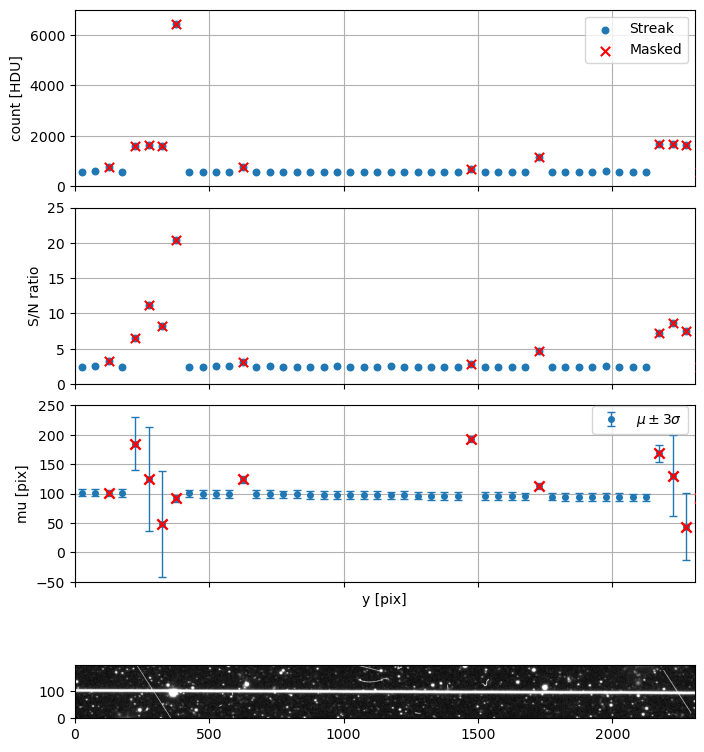

In [ ]:
if paralell_process is False:
    rt_angle_list = [0] * len(initial_gauss_table)
    for row in tqdm(initial_gauss_table):
        if row["file_availablity"] is not True or row["gauss_availability"] is not True:
            continue
        
        streak_ID = row["streak_ID"]
        idx = streakid_to_idx.get(streak_ID, None)
        if idx is None:
            continue

        basename = path.basename(data[idx]["archive_filename"])
        md5sum = data[idx]["md5sum"]
        expnum = data[idx]["expnum"]
        ccdnum = data[idx]["ccdnum"]

        save_path = PATH_image + path.splitext(path.splitext(basename)[0])[0] + "_CCD_{0}".format(ccdnum) + path.splitext(path.splitext(basename)[0])[1] + path.splitext(basename)[1]

        section   = row["initial_gauss_y"]
        amplitude = row["initial_amplitude"]
        ground    = row["initial_ground"]
        mu        = row["initial_mu"]
        sigma     = row["initial_sigma"]

        s_n       = (amplitude+ground)/ground

        mu_initial_mask = (mu > 50) & (mu < 150) & (sigma > 0)
        mu_initial_mask[-1] = False

        ground_mask = mu_initial_mask
        for i in range(0,2):
            _,low,high = sigmaclip(ground[ground_mask],3,3)
            ground_mask = (ground > low) & (ground < high)
        
        s_n_mask = mu_initial_mask & (s_n > 1)
        for i in range(0,2):
            _,low,high = sigmaclip(s_n[s_n_mask],3,3)
            s_n_mask = (s_n > low) & (s_n < high) & (s_n > 1)
        
        for i in range(0,1):
            _,low,high = sigmaclip(mu[mu_initial_mask],2,2)
            mu_mask = (mu > low) & (mu < high)
        
        sigma_mask = mu_initial_mask
        for i in range(0,1):
            _,low,high = sigmaclip(sigma[mu_initial_mask],3,3)
            sigma_mask = (sigma > low) & (sigma < high)
        
        mask = ground_mask & s_n_mask & mu_mask & sigma_mask & mu_initial_mask

        if np.sum(mask)>1:
            res = np.polyfit(np.asarray((section+25)[mask],dtype=float),np.asarray(mu[mask],dtype=float),1)
            rt_angle = row["initial_rt_angle"] + np.arctan(res[0]) * (180 / np.pi)
        else:
            rt_angle = None
        rt_angle_list[idx] = rt_angle

        #--------------------------------#
        # Plot                           #
        #--------------------------------#
        # # Read Image file
        # hdu = fits.open(save_path)
        # main_header = hdu[0].header
        # ccd_header = hdu[1].header
        # ccd_data = hdu[1].data
        # ccd_wcs = WCS(ccd_header)

        # ccd_data = fits.getdata(save_path,1)
        # rotated_img = sp.imgrotation.rotate_image(ccd_data, row["initial_rt_angle"], row["initial_streak_coord"], True, 100)

        # ## Settings
        # y_pix = section + 25

        # fig, ax = plt.subplots(
        #     4, 1,
        #     figsize=(8, 10),
        #     sharex=True,
        #     gridspec_kw={"hspace": 0.12}
        # )

        # def clip_to_ylim(y, ylim):
        #     y = np.asarray(y, dtype=float)
        #     return np.clip(y, ylim[0], ylim[1])

        # ## Masked point handling
        # masked = ~np.asarray(mask, dtype=bool)
        # unmasked = np.asarray(mask, dtype=bool)

        # ## Amplitude + Background
        # amp_bkg = np.asarray(amplitude + ground, dtype=float)
        # ground_arr = np.asarray(ground, dtype=float)

        # # y limit (auto)
        # # ylim0 = [
        # #     np.nanpercentile(amp_bkg, 1),
        # #     np.nanpercentile(amp_bkg, 99)
        # # ]

        # # y limit (fixed)
        # ylim0 = [0, 7000]

        # amp_bkg_clip = clip_to_ylim(amp_bkg, ylim0)
        # ground_clip = clip_to_ylim(ground_arr, ylim0)

        # # Object / satellite counts
        # ax[0].scatter(
        #     y_pix,
        #     amp_bkg_clip,
        #     s=22,
        #     marker="o",
        #     # alpha=0.5,
        #     label="Streak",
        #     zorder=2
        # )

        # ## Background estimate
        # # ax[0].scatter(
        # #     y_pix,
        # #     ground_clip,
        # #     s=18,
        # #     marker="s",
        # #     alpha=0.5,
        # #     label="Background estimate",
        # #     zorder=1
        # # )

        # # masked points
        # ax[0].scatter(
        #     y_pix[masked],
        #     clip_to_ylim(amp_bkg[masked], ylim0),
        #     s=45,
        #     marker="x",
        #     color="red",
        #     linewidths=1.5,
        #     label="Masked",
        #     zorder=10
        # )

        # # ax[0].scatter(
        # #     y_pix[masked],
        # #     clip_to_ylim(ground_arr[masked], ylim0),
        # #     s=45,
        # #     marker="x",
        # #     color="red",
        # #     linewidths=1.5,
        # #     zorder=10
        # # )

        # ax[0].set_ylabel("count [HDU]")
        # ax[0].set_ylim(ylim0)
        # ax[0].legend()
        # ax[0].grid()

        # ## S/N
        # s_n_arr = np.asarray(s_n, dtype=float)

        # # y limit (auto)
        # ylim1 = [
        #     np.nanpercentile(s_n_arr, 1),
        #     np.nanpercentile(s_n_arr, 99)
        # ]

        # # y limit (fixed)
        # ylim1 = [0, 25]

        # s_n_clip = clip_to_ylim(s_n_arr, ylim1)

        # # Object / satellite counts
        # ax[1].scatter(
        #     y_pix,
        #     s_n_clip,
        #     s=22,
        #     marker="o",
        #     # alpha=0.5,
        #     zorder=2
        # )

        # # masked points
        # ax[1].scatter(
        #     y_pix[masked],
        #     clip_to_ylim(s_n_arr[masked], ylim1),
        #     s=45,
        #     marker="x",
        #     color="red",
        #     linewidths=1.5,
        #     label="Masked",
        #     zorder=10
        # )

        # ax[1].set_ylabel("S/N ratio")
        # ax[1].set_ylim(ylim1)
        # ax[1].grid()
        # # ax[1].legend()

        # ## mu ± 3σ
        # mu_arr = np.asarray(mu, dtype=float)
        # sigma_arr = np.asarray(sigma, dtype=float)

        # # y limit
        # ylim2 = [-50, 250]

        # valid_sigma = np.isfinite(sigma_arr) & (sigma_arr > 0)
        # valid_mu = np.isfinite(mu_arr)
        # valid = valid_sigma & valid_mu

        # mu_clip = clip_to_ylim(mu_arr, ylim2)

        # # errorbar
        # ax[2].errorbar(
        #     y_pix[valid],
        #     mu_clip[valid],
        #     yerr=3 * sigma_arr[valid],
        #     fmt="o",
        #     markersize=4,
        #     capsize=3,
        #     elinewidth=1,
        #     # alpha=0.5,
        #     label=r"$\mu \pm 3\sigma$",
        #     zorder=2
        # )

        # # masked points
        # masked_valid_mu = masked & valid_mu

        # ax[2].scatter(
        #     y_pix[masked_valid_mu],
        #     clip_to_ylim(mu_arr[masked_valid_mu], ylim2),
        #     s=55,
        #     marker="x",
        #     color="red",
        #     linewidths=1.7,
        #     # label="Masked",
        #     zorder=10
        # )

        # ax[2].set_ylim(ylim2)
        # ax[2].set_xlabel("y [pix]")
        # ax[2].set_ylabel("mu [pix]")
        # ax[2].legend(loc="upper right", bbox_to_anchor=(1, 1.035))
        # ax[2].grid()

        # ## image
        # ax[3].imshow(
        #     rotated_img,
        #     cmap="gray",
        #     origin="lower",
        #     vmin=np.percentile(rotated_img, 5),
        #     vmax=np.percentile(rotated_img, 95)
        # )

        # plt.show()

**Determine rotation angle (parallel processing)**

In [ ]:
if paralell_process:
    rt_angle_list = [0] * len(initial_gauss_table)

    def process_row(row):
        if row["file_availablity"] is not True or row["gauss_availability"] is not True:
            return None, None

        streak_ID = row["streak_ID"]
        idx = streakid_to_idx.get(streak_ID, None)
        if idx is None:
            return None, None

        section   = np.array(row["initial_gauss_y"])
        amplitude = np.array(row["initial_amplitude"])
        ground    = np.array(row["initial_ground"])
        mu        = np.array(row["initial_mu"])
        sigma     = np.array(row["initial_sigma"])

        try:
            s_n = (amplitude + ground) / ground

            mu_initial_mask = (mu > 50) & (mu < 150) & (sigma > 0)
            if len(mu_initial_mask) > 0:
                mu_initial_mask[-1] = False

            if np.sum(mu_initial_mask) < 2:
                return idx, None

            ground_mask = mu_initial_mask.copy()
            for _ in range(2):
                if np.sum(ground_mask) < 2:
                    break
                _, low, high = sigmaclip(ground[ground_mask], 3, 3)
                ground_mask = (ground > low) & (ground < high)

            s_n_mask = mu_initial_mask & (s_n > 1)
            for _ in range(2):
                if np.sum(s_n_mask) < 2:
                    break
                _, low, high = sigmaclip(s_n[s_n_mask], 3, 3)
                s_n_mask = (s_n > low) & (s_n < high) & (s_n > 1)

            _, low, high = sigmaclip(mu[mu_initial_mask], 2, 2)
            mu_mask = (mu > low) & (mu < high)

            _, low, high = sigmaclip(sigma[mu_initial_mask], 3, 3)
            sigma_mask = (sigma > low) & (sigma < high)

            mask = ground_mask & s_n_mask & mu_mask & sigma_mask & mu_initial_mask

            if np.sum(mask) > 1:
                res = np.polyfit((section + 25)[mask], mu[mask], 1)
                rt_angle = row["initial_rt_angle"] + np.degrees(np.arctan(res[0]))
            else:
                rt_angle = None

            return idx, rt_angle

        except Exception as e:
            print(f"Error in streak_ID={streak_ID}: {e}")
            return idx, None


    valid_rows = [
        row for row in initial_gauss_table
        if row["file_availablity"] is True and row["gauss_availability"] is True
    ]

    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(process_row, row) for row in valid_rows]

        for future in tqdm(as_completed(futures), total=len(futures), desc="Calculating rt_angle"):
            idx, rt_angle = future.result()
            if idx is not None:
                rt_angle_list[idx] = rt_angle

**Save result**

In [ ]:
initial_gauss_table["rt_angle"] = rt_angle_list
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_02_initial_gauss.pkl', 'wb') as f:
# with open('{0}session/workspace_initial_gauss_table.pkl'.format(output_path), 'wb') as f:
    pickle.dump(initial_gauss_table, f)

### Gaussian fitting (second)
**Canvas**

In [47]:
second_gauss_availability_list = [False] * len(data)

gauss_y_list   = [[] for _ in range(len(data))]
amplitude_list = [[] for _ in range(len(data))]
ground_list    = [[] for _ in range(len(data))]
mu_list        = [[] for _ in range(len(data))]
sigma_list     = [[] for _ in range(len(data))]

**Gaussian fitting (single processing)**

In [ ]:
if paralell_process is False:
    for row in tqdm(initial_gauss_table):
        if row["file_availablity"] is not True or row["gauss_availability"] is not True:
            continue
        
        streak_ID = row["streak_ID"]
        idx = streakid_to_idx.get(streak_ID, None)
        if idx is None:
            continue

        basename = path.basename(data[idx]["archive_filename"])
        md5sum = data[idx]["md5sum"]
        expnum = data[idx]["expnum"]
        ccdnum = data[idx]["ccdnum"]

        save_path = PATH_image + path.splitext(path.splitext(basename)[0])[0] + "_CCD_{0}".format(ccdnum) + path.splitext(path.splitext(basename)[0])[1] + path.splitext(basename)[1]

        # Read Image file
        hdu = fits.open(save_path)
        main_header = hdu[0].header
        ccd_header = hdu[1].header
        ccd_data = hdu[1].data
        ccd_wcs = WCS(ccd_header)

        try:
            rotated_img = sp.imgrotation.rotate_image(ccd_data, row["rt_angle"], row["initial_streak_coord"], True, 100)
        except:
            print("Error : Streak length is too short (EXPNUM : {0} / CCDNUM : {1} | Streak ID {2})".format(expnum,ccdnum,streak_ID))
            continue

        try:
            if len(rotated_img[0]) < 50:
                print("Error : Streak length is too short (EXPNUM : {0} / CCDNUM : {1} | Streak ID {2})".format(expnum,ccdnum,streak_ID))
                continue
        except:
            print("Error : Streak length is too short (EXPNUM : {0} / CCDNUM : {1} | Streak ID {2})".format(expnum,ccdnum,streak_ID))
            continue

        # determine rotation angle
        try:
            section,amplitude,ground,mu,sigma = streak_gaussian_analysis(rotated_img)
            if len(section) > 0:
                gauss_y_list[idx]   = section
                amplitude_list[idx] = amplitude
                ground_list[idx]    = ground
                mu_list[idx]        = mu
                sigma_list[idx]     = sigma
                second_gauss_availability_list[idx] = True
            else:
                print("Error : Gaussian Fitting Failed (EXPNUM : {0} / CCDNUM : {1} | Streak ID {2})".format(expnum,ccdnum,streak_ID))
                continue
        except:
            print("Error : Gaussian Fitting Failed (EXPNUM : {0} / CCDNUM : {1} | Streak ID {2})".format(expnum,ccdnum,streak_ID))
            continue

**Gaussian fitting (parallel processing)**

In [ ]:
if paralell_process:
    def process_row(row):
        if row["file_availablity"] is not True or row["gauss_availability"] is not True:
            return None

        streak_ID = row["streak_ID"]
        idx = streakid_to_idx.get(streak_ID, None)
        if idx is None:
            return None

        basename = path.basename(data[idx]["archive_filename"])
        md5sum = data[idx]["md5sum"]
        expnum = data[idx]["expnum"]
        ccdnum = data[idx]["ccdnum"]

        save_path = (
            PATH_image
            + path.splitext(path.splitext(basename)[0])[0]
            + f"_CCD_{ccdnum}"
            + path.splitext(path.splitext(basename)[0])[1]
            + path.splitext(basename)[1]
        )

        try:
            with fits.open(save_path) as hdu:
                main_header = hdu[0].header
                ccd_header = hdu[1].header
                ccd_data = hdu[1].data
                ccd_wcs = WCS(ccd_header)
        except Exception:
            print(f"Error : Broken FITS file (EXPNUM : {expnum} / CCDNUM : {ccdnum} | Streak ID {streak_ID})")
            return None

        try:
            rotated_img = sp.imgrotation.rotate_image(
                ccd_data,
                row["rt_angle"],
                row["initial_streak_coord"],
                True,
                100
            )
        except Exception:
            print(f"Error : Streak length is too short (EXPNUM : {expnum} / CCDNUM : {ccdnum} | Streak ID {streak_ID})")
            return None

        try:
            if len(rotated_img[0]) < 50:
                print(f"Error : Streak length is too short (EXPNUM : {expnum} / CCDNUM : {ccdnum} | Streak ID {streak_ID})")
                return None
        except Exception:
            print(f"Error : Streak length is too short (EXPNUM : {expnum} / CCDNUM : {ccdnum} | Streak ID {streak_ID})")
            return None

        try:
            section, amplitude, ground, mu, sigma = streak_gaussian_analysis(rotated_img)

            if len(section) > 0:
                return (
                    idx,
                    section,
                    amplitude,
                    ground,
                    mu,
                    sigma,
                    True
                )
            else:
                print(f"Error : Gaussian Fitting Failed (EXPNUM : {expnum} / CCDNUM : {ccdnum} | Streak ID {streak_ID})")
                return None

        except Exception:
            print(f"Error : Gaussian Fitting Failed (EXPNUM : {expnum} / CCDNUM : {ccdnum} | Streak ID {streak_ID})")
            return None


    # --- 並列実行 ---
    max_workers = 12

    valid_rows = [
        row for row in initial_gauss_table
        if row["file_availablity"] is True and row["gauss_availability"] is True
    ]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_row, row) for row in valid_rows]

        for future in tqdm(as_completed(futures), total=len(futures), desc="Second Gaussian fitting"):
            result = future.result()
            if result is None:
                continue

            idx, section, amplitude, ground, mu, sigma, flag = result

            gauss_y_list[idx]   = section
            amplitude_list[idx] = amplitude
            ground_list[idx]    = ground
            mu_list[idx]        = mu
            sigma_list[idx]     = sigma
            second_gauss_availability_list[idx] = flag

**Save result**

In [ ]:
gauss_table = initial_gauss_table
gauss_table["second_gauss_availability"] = second_gauss_availability_list
gauss_table["gauss_y"] = gauss_y_list
gauss_table["amplitude"] = amplitude_list
gauss_table["ground"] = ground_list
gauss_table["mu"] = mu_list
gauss_table["sigma"] = sigma_list

with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_02_gauss.pkl', 'wb') as f:
# with open('{0}session/workspace_gauss_table.pkl'.format(output_path), 'wb') as f:
    pickle.dump(gauss_table, f)

**Restore session back-up**

In [ ]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_02_gauss.pkl', 'rb') as f:
    gauss_table = pickle.load(f)

### Image data clean-up
Calculate gauss parameters of second fitting and mask data by them<br>

**Canvas**

In [28]:
sigma_list     = [False] * len(data)
mu_list        = [False] * len(data)
amplitude_list = [False] * len(data)
s_n_list       = [False] * len(data)
mu_std_list    = [False] * len(data)

mask_ratio     = [False] * len(data)

**Mask section fittings (single processing)**

In [ ]:
if paralell_process is False:
    rt_angle_list = [0] * len(gauss_table)
    for row in tqdm(gauss_table):
        if row["file_availablity"] is not True or row["gauss_availability"] is not True or row["second_gauss_availability"] != np.True_:
            continue
        
        streak_ID = row["streak_ID"]
        idx = streakid_to_idx.get(streak_ID, None)
        if idx is None:
            continue

        basename = path.basename(data[idx]["archive_filename"])
        md5sum = data[idx]["md5sum"]
        expnum = data[idx]["expnum"]
        ccdnum = data[idx]["ccdnum"]

        save_path = PATH_image + path.splitext(path.splitext(basename)[0])[0] + "_CCD_{0}".format(ccdnum) + path.splitext(path.splitext(basename)[0])[1] + path.splitext(basename)[1]

        section   = row["gauss_y"][:-2]
        amplitude = row["amplitude"][:-2]
        ground    = row["ground"][:-2]
        mu        = row["mu"][:-2]
        sigma     = row["sigma"][:-2]
        s_n       = (amplitude+ground)/ground

        mu_initial_mask = (mu > 50) & (mu < 150) & (sigma > 0)
        # mu_initial_mask[-1] = False

        ground_mask = mu_initial_mask
        for i in range(0,1):
            _,low,high = sigmaclip(ground[ground_mask],3,3)
            ground_mask = (ground > low) & (ground < high)
        
        s_n_mask = mu_initial_mask & (s_n > 1)
        for i in range(0,1):
            _,low,high = sigmaclip(s_n[s_n_mask],3,3)
            s_n_mask = (s_n > low) & (s_n < high) & (s_n > 1)
        
        for i in range(0,1):
            _,low,high = sigmaclip(mu[mu_initial_mask],2,2)
            mu_mask = (mu > low) & (mu < high)
        
        sigma_mask = mu_initial_mask
        for i in range(0,1):
            _,low,high = sigmaclip(sigma[mu_initial_mask],3,3)
            sigma_mask = (sigma > low) & (sigma < high)
        
        mask = ground_mask & s_n_mask & mu_mask & sigma_mask & mu_initial_mask

        s_n_mean = np.mean(s_n[s_n_mask])
        # if np.sum(s_n[s_n_mask] < s_n_mean) > len(s_n[s_n_mask]) * 2/3:
        #     print("Case 1")
        # else:
        #     print("Case 2")

        sigma_list[idx] = np.mean(sigma[mask])
        mu_list[idx] = np.mean(mu[mask])
        amplitude_list[idx] = np.mean(amplitude[mask])
        s_n_list[idx] = np.mean(s_n[mask])
        mu_std_list[idx] = np.std(mu[mask])
        mask_ratio[idx] = np.sum(mask)/len(section)

        #--------------------------------#
        # Plot                           #
        #--------------------------------#
        # # Read Image file
        # hdu = fits.open(save_path)
        # main_header = hdu[0].header
        # ccd_header = hdu[1].header
        # ccd_data = hdu[1].data
        # ccd_wcs = WCS(ccd_header)

        # ccd_data = fits.getdata(save_path,1)
        # rotated_img = sp.imgrotation.rotate_image(ccd_data, row["initial_rt_angle"], row["initial_streak_coord"], True, 100)

        # ## Settings
        # y_pix = section + 25

        # fig, ax = plt.subplots(
        #     4, 1,
        #     figsize=(8, 10),
        #     sharex=True,
        #     gridspec_kw={"hspace": 0.12}
        # )

        # def clip_to_ylim(y, ylim):
        #     y = np.asarray(y, dtype=float)
        #     return np.clip(y, ylim[0], ylim[1])

        # ## Masked point handling
        # masked = ~np.asarray(mask, dtype=bool)
        # unmasked = np.asarray(mask, dtype=bool)

        # ## Amplitude + Background
        # amp_bkg = np.asarray(amplitude + ground, dtype=float)
        # ground_arr = np.asarray(ground, dtype=float)

        # # y limit (auto)
        # # ylim0 = [
        # #     np.nanpercentile(amp_bkg, 1),
        # #     np.nanpercentile(amp_bkg, 99)
        # # ]

        # # y limit (fixed)
        # ylim0 = [0, 7000]

        # amp_bkg_clip = clip_to_ylim(amp_bkg, ylim0)
        # ground_clip = clip_to_ylim(ground_arr, ylim0)

        # # Object / satellite counts
        # ax[0].scatter(
        #     y_pix,
        #     amp_bkg_clip,
        #     s=22,
        #     marker="o",
        #     # alpha=0.5,
        #     label="Streak",
        #     zorder=2
        # )

        # ## Background estimate
        # # ax[0].scatter(
        # #     y_pix,
        # #     ground_clip,
        # #     s=18,
        # #     marker="s",
        # #     alpha=0.5,
        # #     label="Background estimate",
        # #     zorder=1
        # # )

        # # masked points
        # ax[0].scatter(
        #     y_pix[masked],
        #     clip_to_ylim(amp_bkg[masked], ylim0),
        #     s=45,
        #     marker="x",
        #     color="red",
        #     linewidths=1.5,
        #     label="Masked",
        #     zorder=10
        # )

        # # ax[0].scatter(
        # #     y_pix[masked],
        # #     clip_to_ylim(ground_arr[masked], ylim0),
        # #     s=45,
        # #     marker="x",
        # #     color="red",
        # #     linewidths=1.5,
        # #     zorder=10
        # # )

        # ax[0].set_ylabel("count [HDU]")
        # ax[0].set_ylim(ylim0)
        # ax[0].legend()
        # ax[0].grid()

        # ## S/N
        # s_n_arr = np.asarray(s_n, dtype=float)

        # # y limit (auto)
        # ylim1 = [
        #     np.nanpercentile(s_n_arr, 1),
        #     np.nanpercentile(s_n_arr, 99)
        # ]

        # # y limit (fixed)
        # ylim1 = [0, 25]

        # s_n_clip = clip_to_ylim(s_n_arr, ylim1)

        # # Object / satellite counts
        # ax[1].scatter(
        #     y_pix,
        #     s_n_clip,
        #     s=22,
        #     marker="o",
        #     # alpha=0.5,
        #     zorder=2
        # )

        # # masked points
        # ax[1].scatter(
        #     y_pix[masked],
        #     clip_to_ylim(s_n_arr[masked], ylim1),
        #     s=45,
        #     marker="x",
        #     color="red",
        #     linewidths=1.5,
        #     label="Masked",
        #     zorder=10
        # )

        # ax[1].set_ylabel("S/N ratio")
        # ax[1].set_ylim(ylim1)
        # ax[1].grid()
        # # ax[1].legend()

        # ## mu ± 3σ
        # mu_arr = np.asarray(mu, dtype=float)
        # sigma_arr = np.asarray(sigma, dtype=float)

        # # y limit
        # ylim2 = [-50, 250]

        # valid_sigma = np.isfinite(sigma_arr) & (sigma_arr > 0)
        # valid_mu = np.isfinite(mu_arr)
        # valid = valid_sigma & valid_mu

        # mu_clip = clip_to_ylim(mu_arr, ylim2)

        # # errorbar
        # ax[2].errorbar(
        #     y_pix[valid],
        #     mu_clip[valid],
        #     yerr=3 * sigma_arr[valid],
        #     fmt="o",
        #     markersize=4,
        #     capsize=3,
        #     elinewidth=1,
        #     # alpha=0.5,
        #     label=r"$\mu \pm 3\sigma$",
        #     zorder=2
        # )

        # # masked points
        # masked_valid_mu = masked & valid_mu

        # ax[2].scatter(
        #     y_pix[masked_valid_mu],
        #     clip_to_ylim(mu_arr[masked_valid_mu], ylim2),
        #     s=55,
        #     marker="x",
        #     color="red",
        #     linewidths=1.7,
        #     # label="Masked",
        #     zorder=10
        # )

        # ax[2].set_ylim(ylim2)
        # ax[2].set_xlabel("y [pix]")
        # ax[2].set_ylabel("mu [pix]")
        # ax[2].legend(loc="upper right", bbox_to_anchor=(1, 1.035))
        # ax[2].grid()

        # ## image
        # ax[3].imshow(
        #     rotated_img,
        #     cmap="gray",
        #     origin="lower",
        #     vmin=np.percentile(rotated_img, 5),
        #     vmax=np.percentile(rotated_img, 95)
        # )

        # plt.show()

**Mask section fittings (paralell processing)**

In [ ]:
if paralell_process:
    def process_row(row):
        if (
            row["file_availablity"] is not True
            or row["gauss_availability"] is not True
            or row["second_gauss_availability"] != np.True_
        ):
            return None

        streak_ID = row["streak_ID"]
        idx = streakid_to_idx.get(streak_ID, None)
        if idx is None:
            return None

        section   = np.asarray(row["gauss_y"][:-2])
        amplitude = np.asarray(row["amplitude"][:-2])
        ground    = np.asarray(row["ground"][:-2])
        mu        = np.asarray(row["mu"][:-2])
        sigma     = np.asarray(row["sigma"][:-2])

        try:
            if len(section) == 0:
                return None

            s_n = (amplitude + ground) / ground

            mu_initial_mask = (mu > 50) & (mu < 150) & (sigma > 0)

            if np.sum(mu_initial_mask) == 0:
                return idx, None, None, None, None, None, None

            ground_mask = mu_initial_mask.copy()
            for _ in range(1):
                if np.sum(ground_mask) == 0:
                    break
                _, low, high = sigmaclip(ground[ground_mask], 3, 3)
                ground_mask = (ground > low) & (ground < high)

            s_n_mask = mu_initial_mask & (s_n > 1)
            for _ in range(1):
                if np.sum(s_n_mask) == 0:
                    break
                _, low, high = sigmaclip(s_n[s_n_mask], 3, 3)
                s_n_mask = (s_n > low) & (s_n < high) & (s_n > 1)

            if np.sum(mu_initial_mask) == 0:
                return idx, None, None, None, None, None, None
            for _ in range(1):
                _, low, high = sigmaclip(mu[mu_initial_mask], 2, 2)
                mu_mask = (mu > low) & (mu < high)

            sigma_mask = mu_initial_mask.copy()
            for _ in range(1):
                if np.sum(mu_initial_mask) == 0:
                    break
                _, low, high = sigmaclip(sigma[mu_initial_mask], 3, 3)
                sigma_mask = (sigma > low) & (sigma < high)

            mask = ground_mask & s_n_mask & mu_mask & sigma_mask & mu_initial_mask

            if np.sum(mask) == 0:
                return idx, None, None, None, None, None, 0.0

            sigma_mean = np.mean(sigma[mask])
            mu_mean = np.mean(mu[mask])
            amplitude_mean = np.mean(amplitude[mask])
            s_n_mean = np.mean(s_n[mask])
            mu_std = np.std(mu[mask])
            ratio = np.sum(mask) / len(section)

            return idx, sigma_mean, mu_mean, amplitude_mean, s_n_mean, mu_std, ratio

        except Exception as e:
            print(f"Error in streak_ID={streak_ID}: {e}")
            return None


    max_workers = 12

    valid_rows = [
        row for row in gauss_table
        if (
            row["file_availablity"] is True
            and row["gauss_availability"] is True
            and row["second_gauss_availability"] == np.True_
        )
    ]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_row, row) for row in valid_rows]

        for future in tqdm(as_completed(futures), total=len(futures), desc="Calculating statistics"):
            result = future.result()
            if result is None:
                continue

            idx, sigma_mean, mu_mean, amplitude_mean, s_n_mean, mu_std, ratio = result

            if idx is None:
                continue

            sigma_list[idx] = sigma_mean
            mu_list[idx] = mu_mean
            amplitude_list[idx] = amplitude_mean
            s_n_list[idx] = s_n_mean
            mu_std_list[idx] = mu_std
            mask_ratio[idx] = ratio

**Save to canvas**

In [ ]:
amplitude_list = np.array(amplitude_list)
mu_list = np.array(mu_list)
mu_std_list = np.array(mu_std_list)
sigma_list = np.array(sigma_list)
s_n_list = np.array(s_n_list)
mask_ratio = np.array(mask_ratio)

gauss_table["amplitude_mean"] = amplitude_list
gauss_table["mu_mean"] = mu_list
gauss_table["mu_std"] = mu_std_list
gauss_table["sigma_mean"] = sigma_list
gauss_table["s_n_mean"] = s_n_list
gauss_table["mask_ratio"] = mask_ratio

**Histogram (A)**

Text(0, 0.5, 'Count')

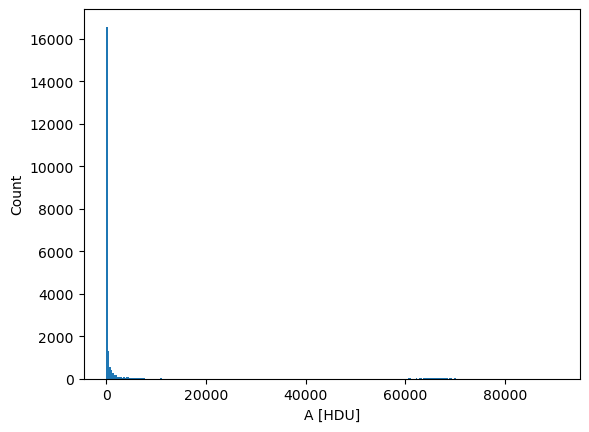

In [20]:
_ = plt.hist(amplitude_list[(amplitude_list != False)], bins="auto")
plt.xlabel("A [HDU]")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

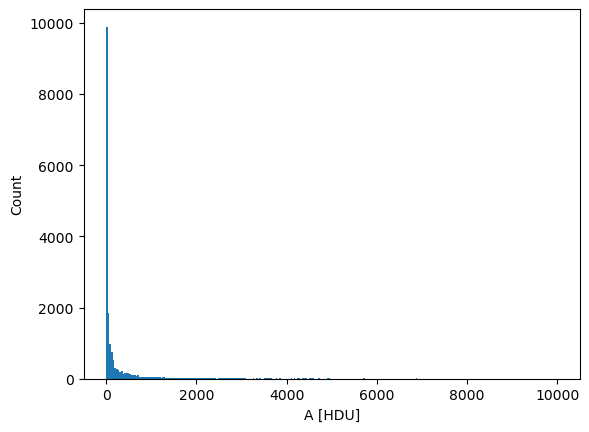

In [21]:
_ = plt.hist(amplitude_list[(amplitude_list != False) & (amplitude_list < 10000) & (amplitude_list > 0)], bins="auto")
plt.xlabel("A [HDU]")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

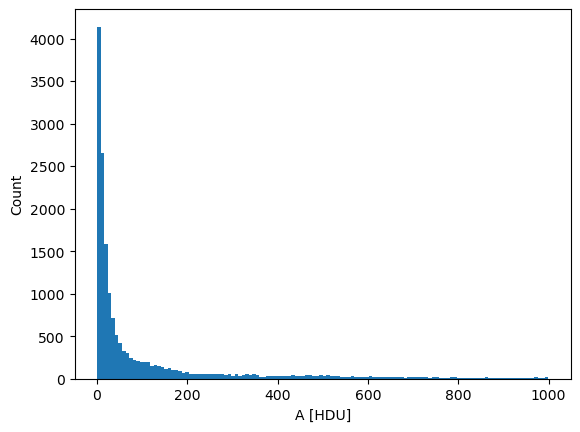

In [22]:
_ = plt.hist(amplitude_list[(amplitude_list != False) & (amplitude_list < 1000) & (amplitude_list > 0)], bins="auto")
plt.xlabel("A [HDU]")
plt.ylabel("Count")

**Histogram (s/n)**

Text(0, 0.5, 'Count')

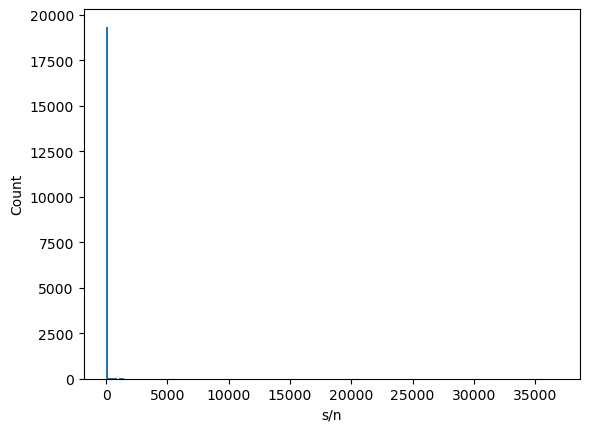

In [27]:
_ = plt.hist(s_n_list[s_n_list != False], bins="auto")
plt.xlabel("s/n")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

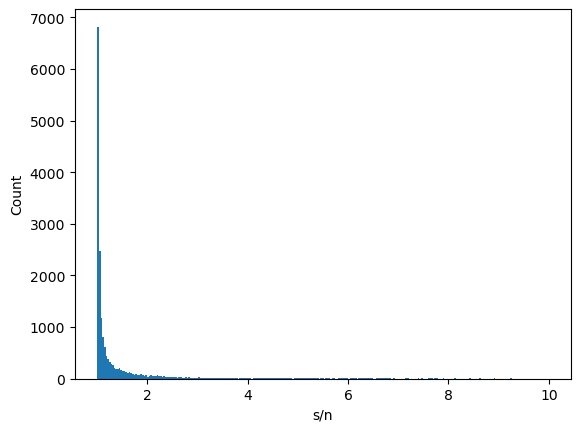

In [28]:
_ = plt.hist(s_n_list[(s_n_list != False) & (s_n_list < 10) & (s_n_list > 1)], bins="auto")
plt.xlabel("s/n")
plt.ylabel("Count")

**Histogram (mu)**

Text(0, 0.5, 'Count')

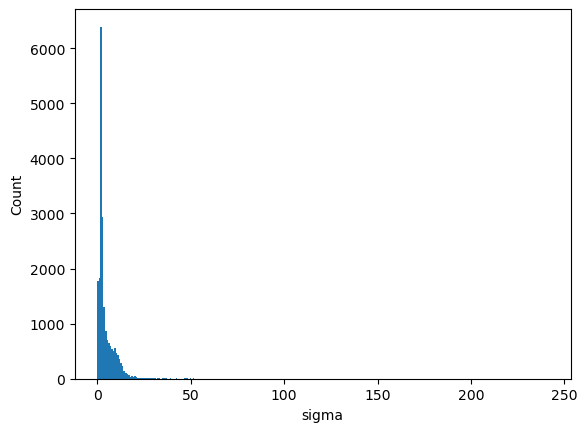

In [29]:
_ = plt.hist(sigma_list[sigma_list != False], bins="auto")
plt.xlabel("sigma")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

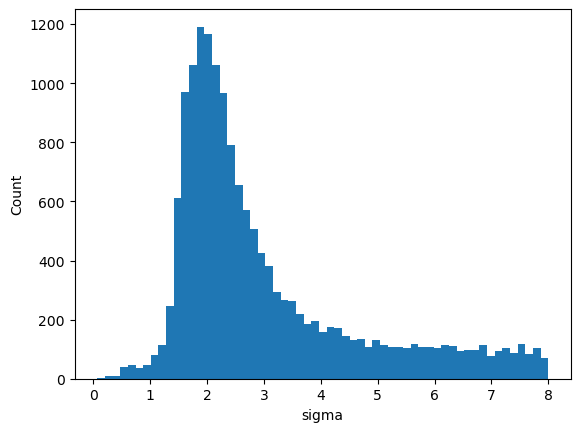

In [32]:
_ = plt.hist(sigma_list[(sigma_list != False) & (sigma_list < 8) & (sigma_list > 0)], bins="auto")
plt.xlabel("sigma")
plt.ylabel("Count")

**Histogram (std_mu)**

Text(0, 0.5, 'Count')

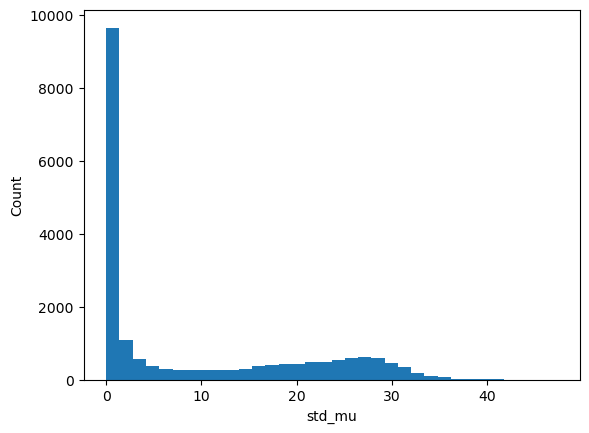

In [33]:
_ = plt.hist(mu_std_list[mu_std_list != False], bins="auto")
plt.xlabel("std_mu")
plt.ylabel("Count")

**Histogram (mask_count)**

Text(0, 0.5, 'Count')

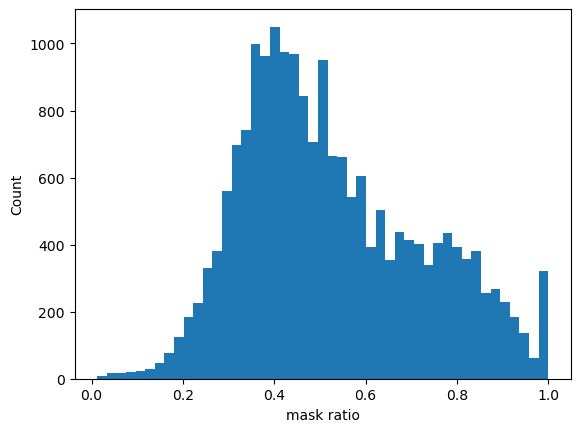

In [35]:
_ = plt.hist(mask_ratio[mask_ratio != False], bins="auto")
plt.xlabel("mask ratio")
plt.ylabel("Count")

**Masked by A, sigma and S/N**

In [43]:
mask_1 = (gauss_table["amplitude_mean"] > 0) & (gauss_table["amplitude_mean"] < 1000)
mask_2 = (gauss_table["sigma_mean"]) > 1 & (gauss_table["sigma_mean"] < 16)
mask_3 = (gauss_table["s_n_mean"] > 1) & (gauss_table["s_n_mean"] < 4)
mask = mask_1 & mask_2 & mask_3

**Save as CSV**

In [ ]:
cleaned_data = hstack([data[mask],gauss_table[mask]])
cleaned_data.remove_column('streak_ID')
data[mask].write(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_02_masked_by_gauss.csv', overwrite = True)

**Save session**

In [ ]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_02_masked_by_gauss.pkl', 'wb') as f:
# with open('{0}session/workspace_cleanedup_list.pkl'.format(output_path), 'wb') as f:
    pickle.dump(cleaned_data, f)